# Bayesian Networks with the Pima Diabetes Dataset

1. Load the Pima diabetes dataset.
2. Select and discretize a few variables.
3. Define a small Bayesian network by hand.
4. Learn the conditional probability tables from data.
5. Perform probabilistic inference.
6. Optionally learn a graph structure from the data using BIC-based hill climbing.


In [ ]:
#!pip install pgmpy

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from pgmpy.datasets import load_dataset
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

/Users/kimsoonho/miniforge3/envs/csc371/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/kimsoonho/miniforge3/envs/csc371/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## 1. Load the Pima diabetes dataset

In [2]:
dataset = load_dataset("pima_diabetes")
data = dataset.data

print("Shape:", data.shape)
print("Columns:", list(data.columns))
display(data.head())

Shape: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


## 2. Select a few variables and discretize them

To keep the graph readable, we use only `Age`, `BMI`, `Glucose`, and `Outcome`.

The first three are continuous in the original data, so we bin them into a few interpretable categories.

In [5]:
df = data[["Age", "BMI", "Glucose", "Outcome"]].copy()

df["Age"] = pd.cut(
    df["Age"],
    bins=[0, 30, 50, float("inf")],
    labels=["young", "middle", "older"]
)

df["BMI"] = pd.cut(
    df["BMI"],
    bins=[0, 25, 30, float("inf")],
    labels=["normal", "overweight", "obese"]
)

df["Glucose"] = pd.cut(
    df["Glucose"],
    bins=[0, 100, 140, float("inf")],
    labels=["low", "medium", "high"]
)

# Remove any rows that became missing after binning.
df = df.dropna().copy()

display(df.head())
print("Rows after discretization:", len(df))

,Age,BMI,Glucose,Outcome
0,middle,obese,high,1
1,middle,overweight,low,0
2,middle,normal,high,1
3,young,overweight,low,0
4,middle,obese,medium,1


Rows after discretization: 752


In [6]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


Age
Age
young     405
middle    268
older      79
Name: count, dtype: int64

BMI
BMI
obese         462
overweight    179
normal        111
Name: count, dtype: int64

Glucose
Glucose
medium    355
low       205
high      192
Name: count, dtype: int64

Outcome
Outcome
0    488
1    264
Name: count, dtype: int64


## 3. Define a small Bayesian network

For the main demo, we specify the graph ourselves:

- `Age -> BMI`
- `Age -> Glucose`
- `BMI -> Outcome`
- `Glucose -> Outcome`

This is a modeling choice and should not be understood as causal.

In [7]:
model = DiscreteBayesianNetwork([
    ("Age", "BMI"),
    ("Age", "Glucose"),
    ("BMI", "Outcome"),
    ("Glucose", "Outcome"),
])

print("Edges:", list(model.edges()))

Edges: [('Age', 'BMI'), ('Age', 'Glucose'), ('BMI', 'Outcome'), ('Glucose', 'Outcome')]


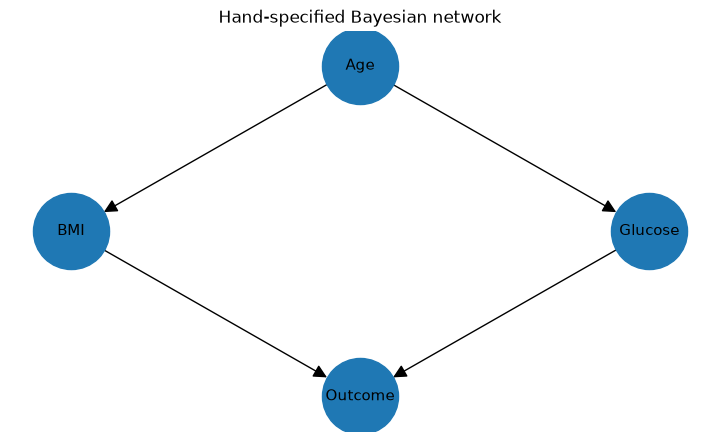

In [8]:
plt.figure(figsize=(7, 4))
pos = {
    "Age": (0, 1),
    "BMI": (-1, 0),
    "Glucose": (1, 0),
    "Outcome": (0, -1),
}
nx.draw(
    model,
    pos=pos,
    with_labels=True,
    node_size=3000,
    font_size=11,
    arrowsize=20,
)
plt.title("Hand-specified Bayesian network")
plt.show()

## 4. Learn the conditional probability tables from data

The graph structure is fixed, but the probabilities are estimated from the dataset.

In [9]:
from pgmpy.estimators import BayesianEstimator

estimator = BayesianEstimator(model, df)

cpds = estimator.get_parameters(
    prior_type="BDeu",
    equivalent_sample_size=5
)

model.add_cpds(*cpds)

print("Model valid:", model.check_model())

Model valid: True


/var/folders/yg/k7j2trxd76j75wkxzq0v2s5c0000gp/T/ipykernel_6817/857588145.py:3: FutureWarning: `pgmpy.estimators.BayesianEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteBayesianEstimator` instead.
  estimator = BayesianEstimator(model, df)


In [10]:
print(model.get_cpds("Outcome"))

+------------+---------------+-----+--------------------+
| BMI        | BMI(normal)   | ... | BMI(overweight)    |
+------------+---------------+-----+--------------------+
| Glucose    | Glucose(high) | ... | Glucose(medium)    |
+------------+---------------+-----+--------------------+
| Outcome(0) | 0.5           | ... | 0.7298099762470309 |
+------------+---------------+-----+--------------------+
| Outcome(1) | 0.5           | ... | 0.2701900237529692 |
+------------+---------------+-----+--------------------+


## 5. Probabilistic inference

A Bayesian network models a joint distribution, so we can ask many different conditional probability questions.

In [11]:
infer = VariableElimination(model)

### Baseline probability of diabetes outcome

In [12]:
infer.query(variables=["Outcome"])

<DiscreteFactor representing phi(Outcome:2) at 0x10770ba10>

### Condition on high glucose

In [14]:
q = infer.query(
    variables=["Outcome"],
    evidence={"Glucose": "high"}
)

In [15]:
print(q)

+------------+----------------+
| Outcome    |   phi(Outcome) |
+============+================+
| Outcome(0) |         0.3555 |
+------------+----------------+
| Outcome(1) |         0.6445 |
+------------+----------------+


### Add BMI evidence

In [16]:
q = infer.query(
    variables=["Outcome"],
    evidence={
        "Glucose": "high",
        "BMI": "obese",
    }
)

In [17]:
print(q)

+------------+----------------+
| Outcome    |   phi(Outcome) |
+============+================+
| Outcome(0) |         0.2442 |
+------------+----------------+
| Outcome(1) |         0.7558 |
+------------+----------------+


### Add age evidence

In [18]:
q = infer.query(
    variables=["Outcome"],
    evidence={
    }
)

In [19]:
print(q)

+------------+----------------+
| Outcome    |   phi(Outcome) |
+============+================+
| Outcome(0) |         0.6536 |
+------------+----------------+
| Outcome(1) |         0.3464 |
+------------+----------------+


In [20]:
q = infer.query(
    variables=["Outcome"],
    evidence={
        "Glucose": "high",
        "BMI": "obese",
        "Age": "older",
    }
)

In [21]:
print(q)

+------------+----------------+
| Outcome    |   phi(Outcome) |
+============+================+
| Outcome(0) |         0.2442 |
+------------+----------------+
| Outcome(1) |         0.7558 |
+------------+----------------+


In [23]:
q = infer.query(
    variables=["Outcome"],
    evidence={
        "Age": "older"
    }
)
print(q)

+------------+----------------+
| Outcome    |   phi(Outcome) |
+============+================+
| Outcome(0) |         0.5636 |
+------------+----------------+
| Outcome(1) |         0.4364 |
+------------+----------------+


### Query a different variable

Because this is a joint probabilistic model rather than only a classifier, we can query another node as well.

In [26]:
q = infer.query(
    variables=["BMI"],
    evidence={
        "Age": "older",
        "Outcome": 0,
    }
)
print(q)

+-----------------+------------+
| BMI             |   phi(BMI) |
+=================+============+
| BMI(normal)     |     0.2703 |
+-----------------+------------+
| BMI(obese)      |     0.4289 |
+-----------------+------------+
| BMI(overweight) |     0.3008 |
+-----------------+------------+
